# RL agent sims (260624): scanning, wall visibility, and arena position

40 social (2-agent) inference runs from `~/Unity/Octagon/simulations/2606/260624`. First models with **110° FoV** (down from ~130°). Notes (`results/2606/260624/notes260624.txt`): identical to the 260623 social models except the **step-penalty *break* for choosing no movement** is commented out, to test why social agents stopped scanning in the ITI and instead stood still until a wall came into view.

3 main points:
1. How much do agents move and rotate during ITI?
2. Latency until a trial wall enters the FoV after slice onset.
3. Centrality

**Design (2×2, 10 models per cell):**

| Group | Models | No-movement penalty-break | Rnd |
|---|---|---|---|
| `nobreak.Rnd01` | 1–10  | removed  | 0.01 |
| `nobreak.Rnd02` | 11–20 | removed  | 0.02 |
| `break.Rnd01`   | 21–30 | restored | 0.01 |
| `break.Rnd02`   | 31–40 | restored | 0.02 |

Main contrast: penalty-break **removed (1–20)** vs **restored (21–40)**. Hypothesis: with the exemption removed, standing still costs reward, so agents should move/scan more.

**Choices:** FoV = 110.0; both agents pooled (self-play); **ITI** taken as trial end → next slice onset (the ITI + trial-started epochs. Pipeline reused from `parse_data/` (`prepare_sim_data` → `preprocess_sim`).

In [3]:
import os
import io
import contextlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import data_strings
import globals
from parse_data import prepare_sim_data, identify_sim_filepaths
import data_extraction.get_indices as get_indices
import trajectory_analysis.trajectory_headangle as trajectory_headangle
import plotting.plot_octagon as plot_octagon

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

# these models are in a dated subfolder
# SIM_DATA_FOLDER = os.path.expanduser('~/Unity/Octagon/simulations/2606/260624')
SIM_DATA_FOLDER = os.path.join(data_strings.SIM_DATA_FOLDER, '2606', '260624')


CURRENT_FOV = 110.0                 # agent camera FoV (total degrees); get_wall_visible tests theta < FoV/2
FS = globals.RECORDING_FREQUENCY    # 50 Hz logging
ARENA_RADIUS = 36.21 / 2            # octagon centred at (0, 0); centrality 1 = centre, 0 = wall
ITI_EPOCHS = [globals.ITI, globals.TRIAL_STARTED]  # "ITI" here = trial end -> next slice onset
STATIONARY_SPEED = 0.05             # units/frame; below this a frame counts as "not moving"
PLAYERS = (0, 1)                    # self-play: pool both agents

In [4]:
# 2x2 groups (inclusive model-number ranges) + a coarse penalty-break factor
GROUPS = {
    'nobreak.Rnd01': (1, 10),
    'nobreak.Rnd02': (11, 20),
    'break.Rnd01':   (21, 30),
    'break.Rnd02':   (31, 40),
}
GROUP_ORDER = list(GROUPS)
PALETTE = {'nobreak.Rnd01': '#4C72B0', 'nobreak.Rnd02': '#8FB0DD',
           'break.Rnd01': '#DD8452', 'break.Rnd02': '#E7B08A'}

def group_of(model):
    for name, (lo, hi) in GROUPS.items():
        if lo <= model <= hi:
            return name
    return None

def break_factor(model):
    # the experimental manipulation: was the no-movement penalty-break present?
    return 'removed' if model <= 20 else 'restored'

group_members = identify_sim_filepaths.group_models(groups=GROUPS, sim_data_folder=SIM_DATA_FOLDER)
for name in GROUP_ORDER:
    print(f"{name:14s} {GROUPS[name]}: {group_members[name]}")
ALL_MODELS = sorted(m for members in group_members.values() for m in members)
print('total models:', len(ALL_MODELS))

nobreak.Rnd01  (1, 10): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
nobreak.Rnd02  (11, 20): [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
break.Rnd01    (21, 30): [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
break.Rnd02    (31, 40): [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
total models: 40


## Metric functions

All three metrics come from one pass per model. To stay memory-safe over 40 models (~90k rows each) the main loop loads one model, computes everything, then discards its dataframe.

In [ ]:
def iti_metrics(df, player_id):
    ''' One row per ITI (a maximal run of ITI/trial-started frames, i.e. trial end -> next slice
        onset). Captures scanning (yaw rotation), movement (path length, stationary fraction) and
        resting centrality for one agent. '''
    xcol = globals.PLAYER_LOC_DICT[player_id]['xloc']
    zcol = globals.PLAYER_LOC_DICT[player_id]['yloc']
    ycol = globals.PLAYER_ROT_DICT[player_id]['yrot'] # yaw rotation (degrees)

    is_iti = df['trial_epoch'].isin(ITI_EPOCHS)
    run_id = (is_iti != is_iti.shift()).cumsum()            # id each contiguous ITI/non-ITI run

    rows = []
    for _, grp in df[is_iti].groupby(run_id[is_iti]):
        yaw = grp[ycol].to_numpy(float); yaw = yaw[~np.isnan(yaw)]
        x = grp[xcol].to_numpy(float); z = grp[zcol].to_numpy(float)
        ok = ~np.isnan(x) & ~np.isnan(z); x, z = x[ok], z[ok]
        if len(yaw) < 3 or len(x) < 3:
            continue
        unw = np.rad2deg(np.unwrap(np.deg2rad(yaw)))         # unwrap so spins past 180 magnitude don't fold back
        step = np.hypot(np.diff(x), np.diff(z))              # per-frame translation
        rows.append(dict(
            player=player_id,
            n_frames=len(yaw),
            rot_range=float(unw.max() - unw.min()),          # total angular sweep
            rot_total=float(np.abs(np.diff(unw)).sum()),     # cumulative rotation (fidget + sweep)
            path_len=float(step.sum()),                      # distance travelled during the ITI
            stationary_frac=float(np.mean(step < STATIONARY_SPEED)),
            centrality=float(1 - np.mean(np.hypot(x, z)) / ARENA_RADIUS),   # 1 = centre, 0 = wall
        ))
    return pd.DataFrame(rows)


def visibility_metrics(trial, player_id, fov=CURRENT_FOV):
    ''' For one agent on one trial: latency (s) until a trial wall first enters the
        FoV after slice onset, plus visible-at-onset / ever-visible flags. Trial walls come
        from get_walls (the trial's High/Low walls). Returns None if the trial is too short. '''
    with contextlib.redirect_stdout(io.StringIO()):        # get_wall_visible is chatty on debug paths
        wv = trajectory_headangle.get_wall_visible(trial=trial, player_id=player_id, current_fov=fov)
    if isinstance(wv, float) and np.isnan(wv):
        return None
    idxs = [w - 1 for w in get_indices.get_walls(trial=trial)]   # wall number -> row index
    any_vis = wv[idxs, :].any(axis=0)                            # any trial wall visible per frame
    ever = bool(any_vis.any())
    return dict(
        player=player_id,
        latency_s=(int(np.argmax(any_vis)) / FS) if ever else np.nan,  # first True frame -> seconds
        visible_at_onset=bool(any_vis[0]),
        ever_visible=ever,
    )

## Main pass over all 40 models

Builds three tidy tables — `iti_df` (one row per ITI), `vis_df` (one row per trial×agent), `model_meta` — and accumulates a per-group 2D occupancy histogram of ITI positions for the heatmaps. ~1–2 min (visibility dominates).

In [4]:
HIST_BINS = 60
HIST_RANGE = [[-ARENA_RADIUS, ARENA_RADIUS], [-ARENA_RADIUS, ARENA_RADIUS]]
group_occupancy = {g: np.zeros((HIST_BINS, HIST_BINS)) for g in GROUP_ORDER}

iti_records, vis_records, score_records = [], [], []

for model in ALL_MODELS:
    grp = group_of(model)
    with contextlib.redirect_stdout(io.StringIO()):          # silence per-model load/preprocess prints
        df, trial_list = prepare_sim_data.prepare_single_model_data(model, sim_data_folder=SIM_DATA_FOLDER)

    # analysis 1 + 3: ITI movement/scanning/position, pooled over agents
    for pid in PLAYERS:
        w = iti_metrics(df, pid)
        w.insert(0, 'model', model); w.insert(1, 'group', grp)
        iti_records.append(w)
        # occupancy: positions during the ITI
        is_iti = df['trial_epoch'].isin(ITI_EPOCHS)
        x = df.loc[is_iti, globals.PLAYER_LOC_DICT[pid]['xloc']].to_numpy(float)
        z = df.loc[is_iti, globals.PLAYER_LOC_DICT[pid]['yloc']].to_numpy(float)
        ok = ~np.isnan(x) & ~np.isnan(z)
        H, _, _ = np.histogram2d(x[ok], z[ok], bins=HIST_BINS, range=HIST_RANGE)
        group_occupancy[grp] += H

    # analysis 2: wall visibility, both agents, all trials
    for trial in trial_list:
        ttype = trial[globals.TRIAL_TYPE].replace('', np.nan).dropna().unique()
        ttype = ttype[0] if len(ttype) else ''
        for pid in PLAYERS:
            try:
                r = visibility_metrics(trial, pid)
            except (IndexError, ValueError):
                r = None                                     # trial missing slice-onset/trigger
            if r is not None:
                r.update(model=model, group=grp, trial_type=ttype)
                vis_records.append(r)

    # analysis 4: per-trial scoring for AGENT 0 only. A per-agent measure of how well this seat
    # actually does, unlike combined score (which an always-High policy inflates). Per trial,
    # agent 0 scores 1.0 (reached High) / 0.4 (Low) / 0 (lost the race); reward = that score net
    # of agent 0's step/time penalties. score_p1 kept only for a seat-symmetry diagnostic.
    te = df[df['eventDescription'] == globals.TRIAL_END]
    score_records.append(pd.DataFrame(dict(
        model=model, group=grp,
        score_p0=te[globals.PLAYER_0_TRIAL_SCORE].to_numpy(float),
        reward_p0=te[globals.PLAYER_0_TRIAL_REWARD].to_numpy(float),
        score_p1=te[globals.PLAYER_1_TRIAL_SCORE].to_numpy(float))))

    print(f"model {model:2d} ({grp}) done", end='  ')

iti_df = pd.concat(iti_records, ignore_index=True)
vis_df = pd.DataFrame(vis_records)
score_df = pd.concat(score_records, ignore_index=True)
model_meta = pd.DataFrame({'model': ALL_MODELS})
model_meta['group'] = model_meta['model'].map(group_of)
model_meta['break'] = model_meta['model'].map(break_factor)
print(f"\n\nITIs: {len(iti_df)} | trial-agent visibility rows: {len(vis_df)} | scored trials: {len(score_df)}")
tc = score_df.groupby('model').size()
print(f"trials per model: min {tc.min()}, max {tc.max()} (expected ~200; totals comparable if equal)")
print(f"seat check — mean terminal score: agent 0 = {score_df.score_p0.mean():.3f}, "
      f"agent 1 = {score_df.score_p1.mean():.3f} (diff "
      f"{score_df.score_p1.mean() - score_df.score_p0.mean():+.3f}; ~symmetric on average = self-play, "
      f"but individual models can be lopsided)")

model  1 (nobreak.Rnd01) done  

model  2 (nobreak.Rnd01) done  

model  3 (nobreak.Rnd01) done  

model  4 (nobreak.Rnd01) done  

model  5 (nobreak.Rnd01) done  

...

model 36 (break.Rnd02) done  

model 37 (break.Rnd02) done  

model 38 (break.Rnd02) done  

model 39 (break.Rnd02) done  

model 40 (break.Rnd02) done  

ITIs: 15988 | trial-agent visibility rows: 14114 | scored trials: 7954
trials per model: min 196, max 199 (expected ~200; totals comparable if equal)
seat check — mean terminal score: agent 0 = 0.434, agent 1 = 0.442 (diff +0.008; ~symmetric on average = self-play, but individual models can be lopsided)


## Analysis 1 — stand still vs scan in the ITI

Per-model means (pooled over both agents), then the coarse penalty-break contrast. Higher `stationary_frac` and lower `path_len` = more standing still.

In [5]:
iti_by_model = (iti_df.groupby(['group', 'model'])
                [['stationary_frac', 'path_len', 'rot_total', 'rot_range', 'centrality', 'n_frames']]
                .mean().reset_index())
iti_by_model['break'] = iti_by_model['model'].map(break_factor)

print('Per penalty-break condition (mean of per-model means):')
print(iti_by_model.groupby('break')[['stationary_frac', 'path_len', 'rot_total', 'centrality']].mean().round(2))
print('\nPer group:')
print(iti_by_model.groupby('group')[['stationary_frac', 'path_len', 'rot_total', 'centrality']].mean().round(2))
iti_by_model.round(2)

Per penalty-break condition (mean of per-model means):
          stationary_frac  path_len  rot_total  centrality
break                                                     
removed              0.18     37.26    1221.64        0.46
restored             0.44     25.93     838.94        0.45

Per group:
               stationary_frac  path_len  rot_total  centrality
group                                                          
break.Rnd01               0.40     28.36     924.54        0.50
break.Rnd02               0.49     23.50     753.34        0.40
nobreak.Rnd01             0.17     38.14    1246.59        0.51
nobreak.Rnd02             0.19     36.39    1196.70        0.40


,group,model,stationary_frac,path_len,rot_total,rot_range,centrality,n_frames,break
0,break.Rnd01,21,0.32,33.57,1278.92,996.35,0.84,248.86,restored
1,break.Rnd01,22,0.31,33.25,1187.89,887.02,0.85,242.29,restored
2,break.Rnd01,23,0.76,10.10,382.39,56.61,-0.02,238.28,restored
3,break.Rnd01,24,0.44,25.98,813.15,138.62,0.15,240.90,restored
4,break.Rnd01,25,0.27,34.71,1231.42,741.82,0.78,239.33,restored
5,break.Rnd01,26,0.54,18.10,463.54,61.31,-0.04,241.52,restored
6,break.Rnd01,27,0.62,16.98,505.33,187.92,0.03,244.66,restored
7,break.Rnd01,28,0.22,37.67,915.52,264.33,0.83,242.17,restored
8,break.Rnd01,29,0.21,38.15,1260.04,587.14,0.78,243.90,restored
9,break.Rnd01,30,0.28,35.04,1207.21,766.04,0.77,246.40,restored


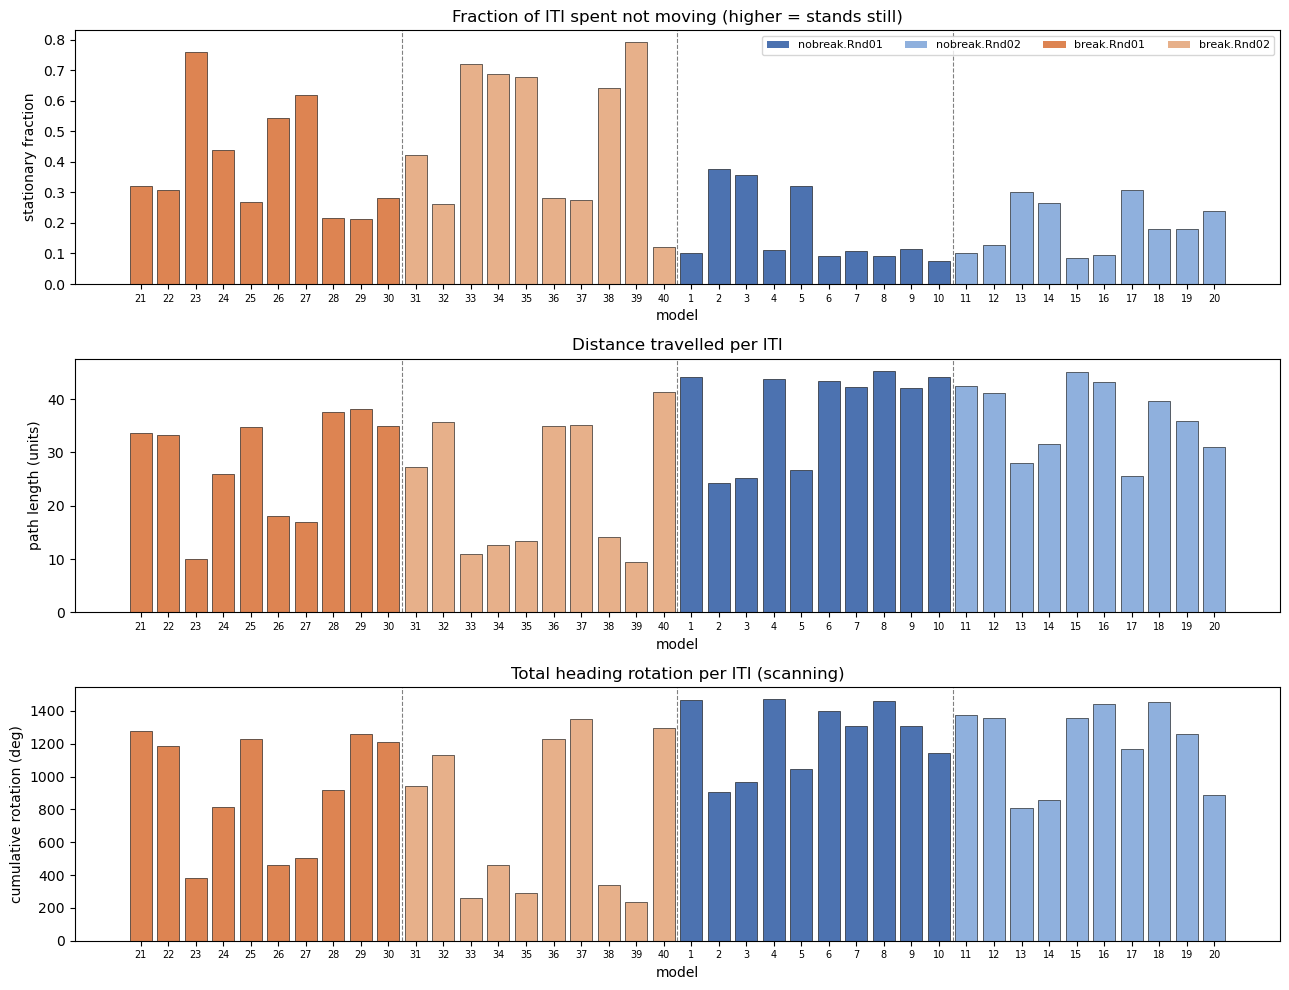

In [6]:
def per_model_panel(ax, col, ylabel, title):
    order = iti_by_model.sort_values(['group', 'model'])
    x = np.arange(len(order))
    ax.bar(x, order[col], color=[PALETTE[g] for g in order['group']], edgecolor='black', linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(order['model'], fontsize=7)
    ax.set_xlabel('model'); ax.set_ylabel(ylabel); ax.set_title(title)
    for b in np.cumsum([(order['group'] == g).sum() for g in GROUP_ORDER])[:-1]:
        ax.axvline(b - 0.5, color='grey', ls='--', lw=0.8)

fig, axes = plt.subplots(3, 1, figsize=(13, 10))
per_model_panel(axes[0], 'stationary_frac', 'stationary fraction', 'Fraction of ITI spent not moving (higher = stands still)')
per_model_panel(axes[1], 'path_len', 'path length (units)', 'Distance travelled per ITI')
per_model_panel(axes[2], 'rot_total', 'cumulative rotation (deg)', 'Total heading rotation per ITI (scanning)')
axes[0].legend(handles=[Patch(facecolor=PALETTE[g], label=g) for g in GROUP_ORDER], ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

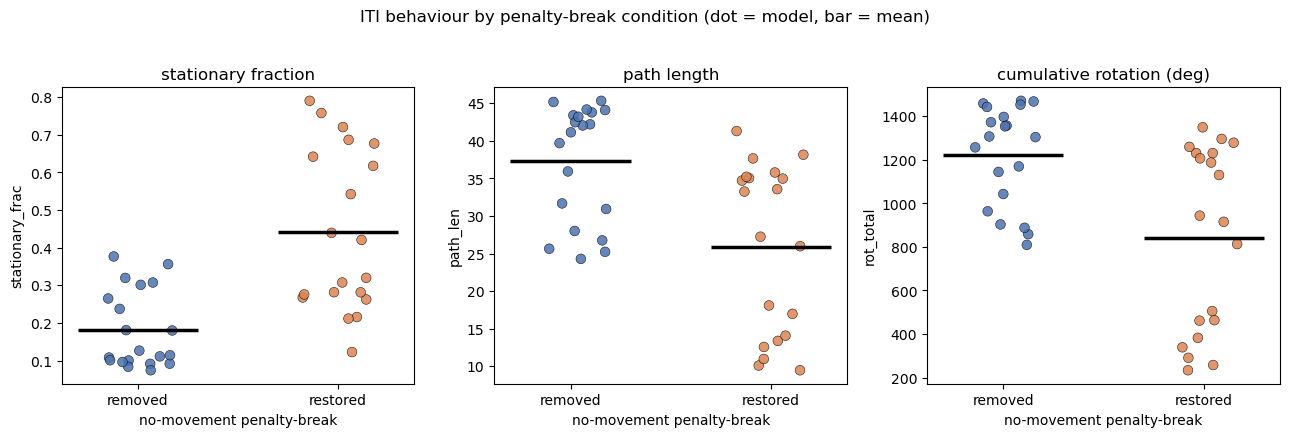

In [7]:
# penalty-break contrast: distribution of per-model values, break removed vs restored
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, col, title in zip(
        axes, ['stationary_frac', 'path_len', 'rot_total'],
        ['stationary fraction', 'path length', 'cumulative rotation (deg)']):
    sns.stripplot(data=iti_by_model, x='break', y=col, order=['removed', 'restored'],
                  hue='break', palette={'removed': '#4C72B0', 'restored': '#DD8452'},
                  size=7, jitter=0.18, alpha=0.85, edgecolor='black', linewidth=0.4, legend=False, ax=ax)
    means = iti_by_model.groupby('break')[col].mean()
    for i, b in enumerate(['removed', 'restored']):
        ax.hlines(means[b], i - 0.3, i + 0.3, color='black', lw=2.5, zorder=5)
    ax.set_title(title); ax.set_xlabel('no-movement penalty-break')
plt.suptitle('ITI behaviour by penalty-break condition (dot = model, bar = mean)', y=1.03)
plt.tight_layout(); plt.show()

## Analysis 2 — do they see walls quickly, or face one way and miss them?

From slice onset, using the FoV visibility machinery on the trial's High/Low walls:
- **visible at onset** — a trial wall already in view when the walls appear (agent happened to face it),
- **latency** — seconds until a trial wall first enters the FoV, among trials where it was *not* already visible,
- **never visible** — a trial wall never entered the FoV before the choice (faced away, missed it).

In [8]:
vis_by_model = vis_df.groupby(['group', 'model']).agg(
    n=('ever_visible', 'size'),
    frac_visible_at_onset=('visible_at_onset', 'mean'),
    frac_never_visible=('ever_visible', lambda s: 1 - s.mean()),
).reset_index()
# mean latency among trials NOT already visible at onset (latency > 0, and did become visible)
late = vis_df[(~vis_df['visible_at_onset']) & vis_df['ever_visible']]
vis_by_model = vis_by_model.merge(
    late.groupby('model')['latency_s'].mean().rename('mean_latency_s_if_not_onset').reset_index(),
    on='model', how='left')
vis_by_model['break'] = vis_by_model['model'].map(break_factor)

print('Per penalty-break condition:')
print(vis_by_model.groupby('break')[['frac_visible_at_onset', 'mean_latency_s_if_not_onset', 'frac_never_visible']].mean().round(3))
print('\nPer group:')
print(vis_by_model.groupby('group')[['frac_visible_at_onset', 'mean_latency_s_if_not_onset', 'frac_never_visible']].mean().round(3))
vis_by_model.round(3)

Per penalty-break condition:
          frac_visible_at_onset  mean_latency_s_if_not_onset  frac_never_visible
break                                                                           
removed                   0.806                        0.265               0.000
restored                  0.794                        0.475               0.006

Per group:
               frac_visible_at_onset  mean_latency_s_if_not_onset  frac_never_visible
group                                                                                
break.Rnd01                    0.776                        0.460               0.008
break.Rnd02                    0.811                        0.491               0.004
nobreak.Rnd01                  0.780                        0.303               0.000
nobreak.Rnd02                  0.832                        0.226               0.000


,group,model,n,frac_visible_at_onset,frac_never_visible,mean_latency_s_if_not_onset,break
0,break.Rnd01,21,398,0.671,0.000,0.262,restored
1,break.Rnd01,22,398,0.686,0.000,0.317,restored
2,break.Rnd01,23,290,0.952,0.000,0.677,restored
3,break.Rnd01,24,350,0.863,0.003,0.529,restored
4,break.Rnd01,25,398,0.681,0.000,0.291,restored
5,break.Rnd01,26,292,0.932,0.007,0.394,restored
6,break.Rnd01,27,292,0.894,0.010,0.661,restored
7,break.Rnd01,28,398,0.681,0.030,0.803,restored
8,break.Rnd01,29,398,0.704,0.025,0.358,restored
9,break.Rnd01,30,398,0.696,0.000,0.302,restored


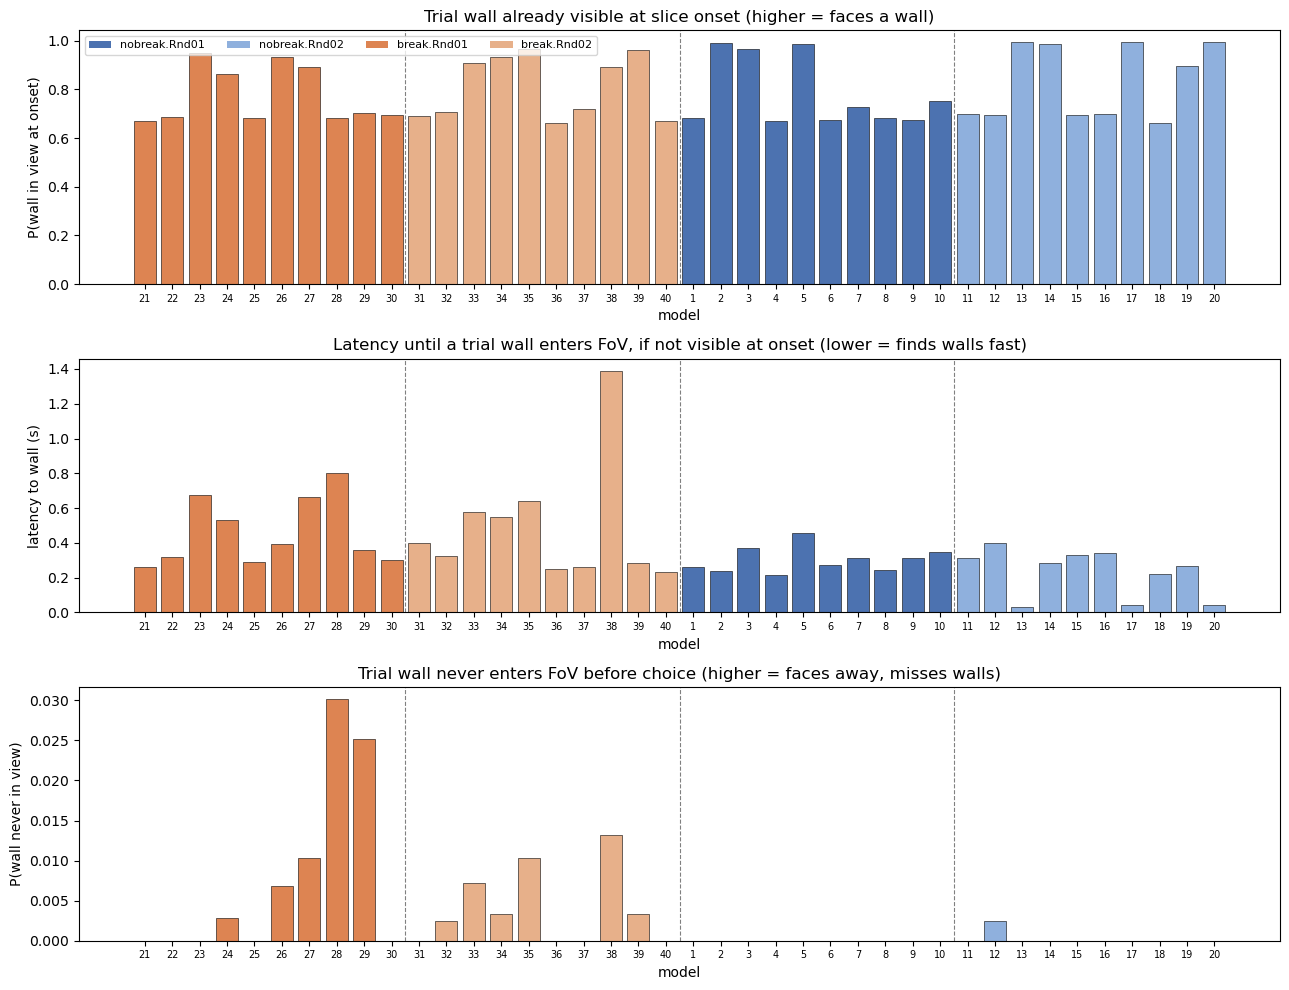

In [9]:
order = vis_by_model.sort_values(['group', 'model'])
x = np.arange(len(order))
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

for ax, col, ylab, title in zip(
        axes,
        ['frac_visible_at_onset', 'mean_latency_s_if_not_onset', 'frac_never_visible'],
        ['P(wall in view at onset)', 'latency to wall (s)', 'P(wall never in view)'],
        ['Trial wall already visible at slice onset (higher = faces a wall)',
         'Latency until a trial wall enters FoV, if not visible at onset (lower = finds walls fast)',
         'Trial wall never enters FoV before choice (higher = faces away, misses walls)']):
    ax.bar(x, order[col], color=[PALETTE[g] for g in order['group']], edgecolor='black', linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(order['model'], fontsize=7)
    ax.set_xlabel('model'); ax.set_ylabel(ylab); ax.set_title(title)
    for b in np.cumsum([(order['group'] == g).sum() for g in GROUP_ORDER])[:-1]:
        ax.axvline(b - 0.5, color='grey', ls='--', lw=0.8)
axes[0].legend(handles=[Patch(facecolor=PALETTE[g], label=g) for g in GROUP_ORDER], ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

## Analysis 3 — central vs peripheral

Resting centrality during the ITI (1 = arena centre, 0 = at a wall), per model, plus per-group occupancy heatmaps of where agents sit in the ITI.

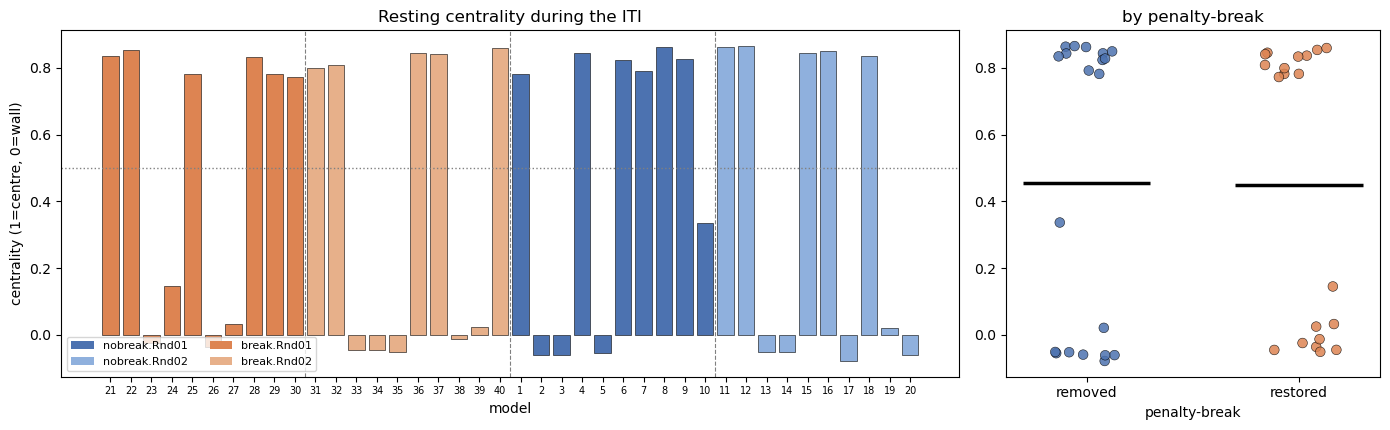

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={'width_ratios': [2.4, 1]})

order = iti_by_model.sort_values(['group', 'model'])
x = np.arange(len(order))
axes[0].bar(x, order['centrality'], color=[PALETTE[g] for g in order['group']], edgecolor='black', linewidth=0.4)
axes[0].axhline(0.5, color='grey', ls=':', lw=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(order['model'], fontsize=7)
axes[0].set_xlabel('model'); axes[0].set_ylabel('centrality (1=centre, 0=wall)')
axes[0].set_title('Resting centrality during the ITI')
for b in np.cumsum([(order['group'] == g).sum() for g in GROUP_ORDER])[:-1]:
    axes[0].axvline(b - 0.5, color='grey', ls='--', lw=0.8)
axes[0].legend(handles=[Patch(facecolor=PALETTE[g], label=g) for g in GROUP_ORDER], ncol=2, fontsize=8)

sns.stripplot(data=iti_by_model, x='break', y='centrality', order=['removed', 'restored'],
              hue='break', palette={'removed': '#4C72B0', 'restored': '#DD8452'},
              size=7, jitter=0.18, alpha=0.85, edgecolor='black', linewidth=0.4, legend=False, ax=axes[1])
means = iti_by_model.groupby('break')['centrality'].mean()
for i, b in enumerate(['removed', 'restored']):
    axes[1].hlines(means[b], i - 0.3, i + 0.3, color='black', lw=2.5, zorder=5)
axes[1].set_title('by penalty-break'); axes[1].set_xlabel('penalty-break'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()

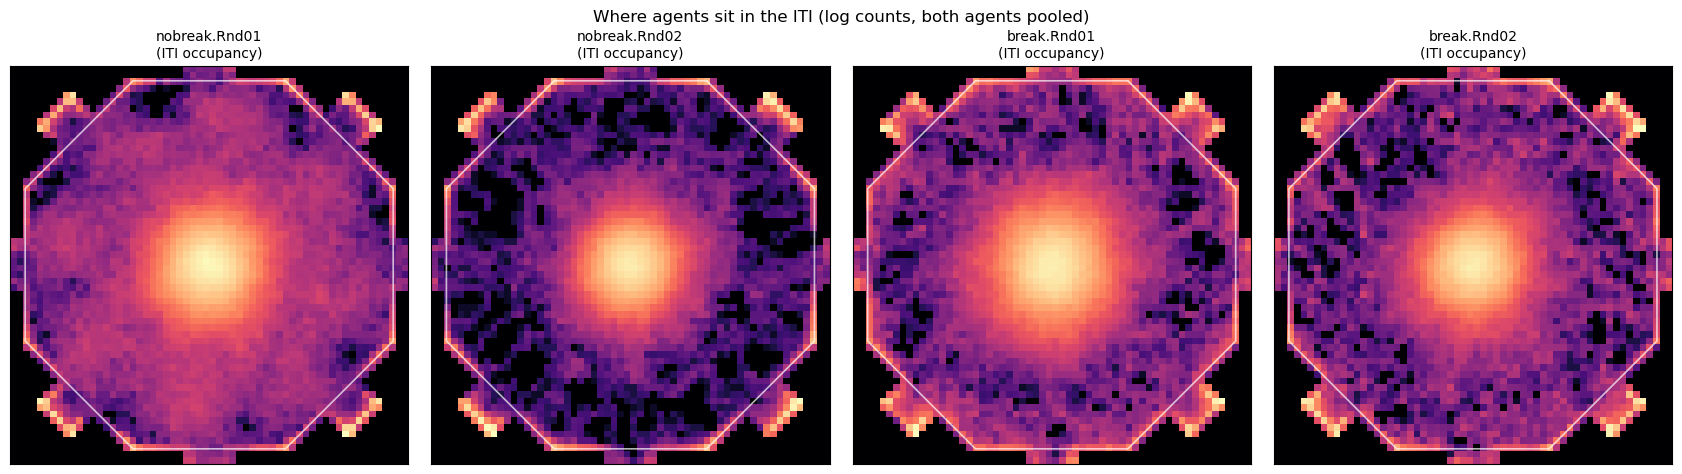

In [11]:
# per-group occupancy heatmaps of ITI position (log-scaled counts) with octagon outline
oct_x, oct_y = plot_octagon.calculate_coordinates(vertex=True)
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
extent = [-ARENA_RADIUS, ARENA_RADIUS, -ARENA_RADIUS, ARENA_RADIUS]
for ax, g in zip(axes, GROUP_ORDER):
    H = group_occupancy[g]
    ax.imshow(np.log1p(H).T, origin='lower', extent=extent, cmap='magma', aspect='equal')
    ax.plot(oct_x, oct_y, color='white', lw=1.2, alpha=0.7)
    ax.set_title(f'{g}\n(ITI occupancy)', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Where agents sit in the ITI (log counts, both agents pooled)', y=1.02)
plt.tight_layout(); plt.show()

## Analysis 4 — scoring effectiveness (agent 0 only)

A first, rough read on model quality, using **agent 0's own** performance rather than the combined score (which an always-High policy inflates without being competitively strong). Per trial agent 0 scores **1.0** (reached High), **0.4** (reached Low) or **0** (lost the race); reward is that score net of agent 0's step/time penalties. Sessions are ~200 trials, so totals are comparable without any time normalisation.
- **total score** — agent 0's cumulative terminal score over the run,
- **trial-averaged score** — the same per trial (mean terminal score),
- **trial-averaged reward** — mean net agent reward (after step/time penalties) = efficiency.

The true test is still a tournament (each model vs *other* models); this only reflects agent 0 within its own session.

In [12]:
eff = score_df.groupby(['group', 'model']).agg(
    n=('score_p0', 'size'),
    total_score=('score_p0', 'sum'),        # agent 0 cumulative terminal score over the run
    mean_score=('score_p0', 'mean'),        # trial-averaged terminal score
    mean_reward=('reward_p0', 'mean'),      # trial-averaged net reward (after step/time penalties)
).reset_index()
eff['break'] = eff['model'].map(break_factor)

print('Per penalty-break condition (mean of per-model means):')
print(eff.groupby('break')[['total_score', 'mean_score', 'mean_reward']].mean().round(3))
print('\nPer group:')
print(eff.groupby('group')[['total_score', 'mean_score', 'mean_reward']].mean().round(3))
print('\nTop 8 models by agent-0 mean reward:')
print(eff.sort_values('mean_reward', ascending=False).head(8)
      [['model', 'group', 'total_score', 'mean_score', 'mean_reward']].round(3).to_string(index=False))
eff.round(3)

Per penalty-break condition (mean of per-model means):
          total_score  mean_score  mean_reward
break                                         
removed         88.44       0.445         0.00
restored        84.13       0.423         0.05

Per group:
               total_score  mean_score  mean_reward
group                                              
break.Rnd01          82.38       0.414        0.025
break.Rnd02          85.88       0.432        0.075
nobreak.Rnd01        88.02       0.443       -0.001
nobreak.Rnd02        88.86       0.447        0.002

Top 8 models by agent-0 mean reward:
 model         group  total_score  mean_score  mean_reward
    39   break.Rnd02         82.0       0.412        0.177
    33   break.Rnd02         84.2       0.423        0.159
    31   break.Rnd02        107.0       0.538        0.138
    23   break.Rnd01         77.0       0.387        0.097
    26   break.Rnd01         83.8       0.421        0.071
    35   break.Rnd02         74.2       0

,group,model,n,total_score,mean_score,mean_reward,break
0,break.Rnd01,21,199,89.6,0.450,0.021,restored
1,break.Rnd01,22,199,86.8,0.436,0.012,restored
2,break.Rnd01,23,199,77.0,0.387,0.097,restored
3,break.Rnd01,24,199,72.4,0.364,-0.018,restored
4,break.Rnd01,25,199,84.2,0.423,-0.006,restored
5,break.Rnd01,26,199,83.8,0.421,0.071,restored
6,break.Rnd01,27,199,71.2,0.358,0.048,restored
7,break.Rnd01,28,199,75.0,0.377,-0.044,restored
8,break.Rnd01,29,199,91.0,0.457,0.029,restored
9,break.Rnd01,30,199,92.8,0.466,0.038,restored


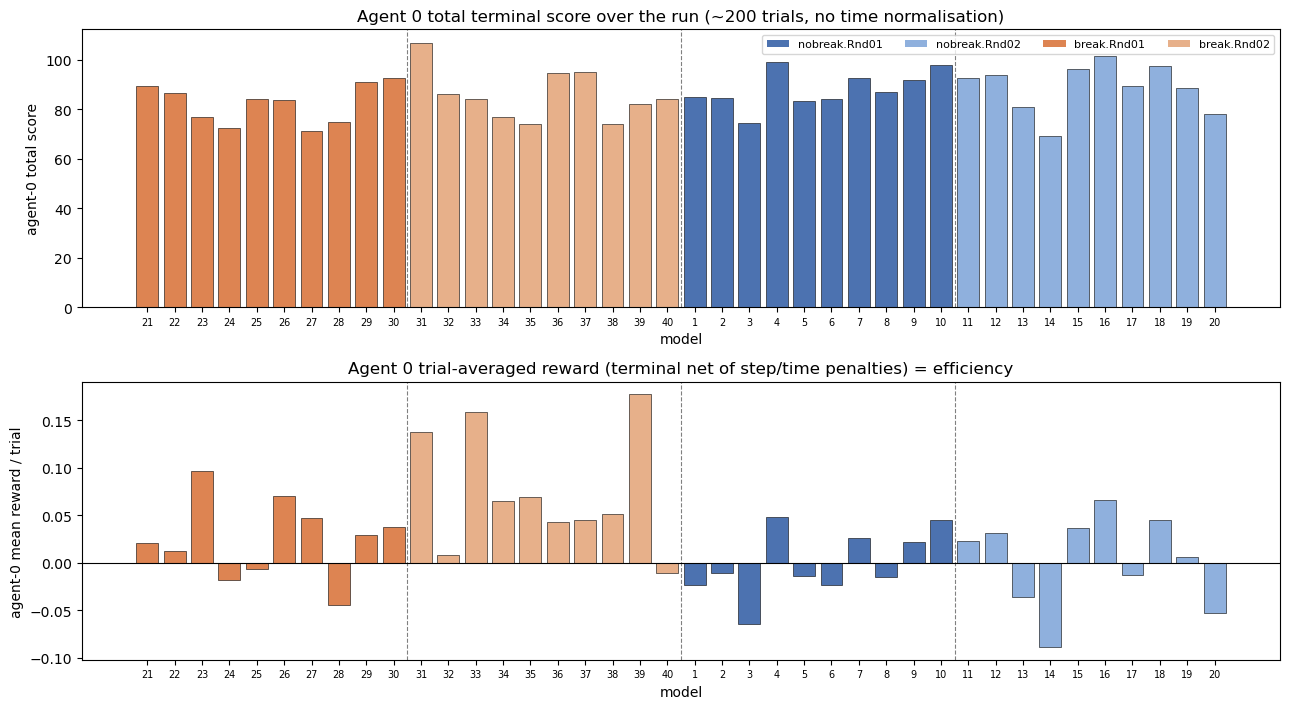

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7.2))
order = eff.sort_values(['group', 'model'])
x = np.arange(len(order))
for ax, col, ylab, title in zip(
        axes, ['total_score', 'mean_reward'],
        ['agent-0 total score', 'agent-0 mean reward / trial'],
        ['Agent 0 total terminal score over the run (~200 trials, no time normalisation)',
         'Agent 0 trial-averaged reward (terminal net of step/time penalties) = efficiency']):
    ax.bar(x, order[col], color=[PALETTE[g] for g in order['group']], edgecolor='black', linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(order['model'], fontsize=7)
    ax.set_xlabel('model'); ax.set_ylabel(ylab); ax.set_title(title)
    for b in np.cumsum([(order['group'] == g).sum() for g in GROUP_ORDER])[:-1]:
        ax.axvline(b - 0.5, color='grey', ls='--', lw=0.8)
axes[1].axhline(0, color='k', lw=0.8)
axes[0].legend(handles=[Patch(facecolor=PALETTE[g], label=g) for g in GROUP_ORDER], ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

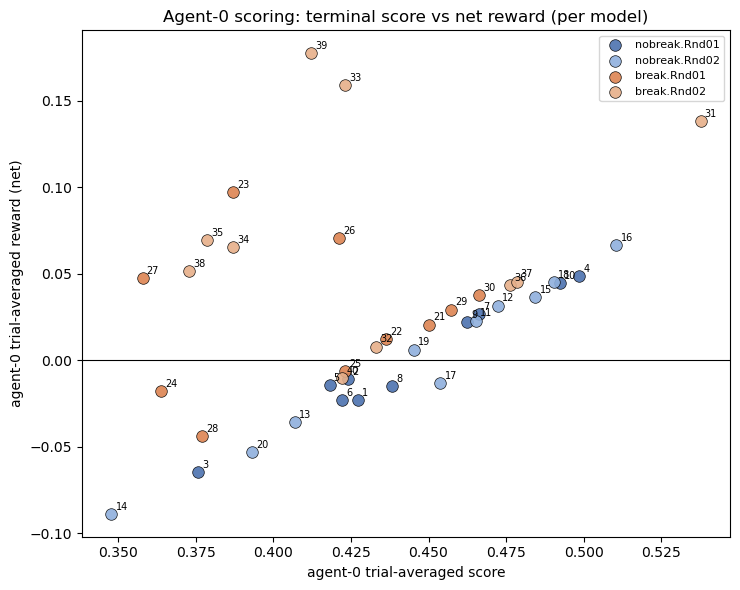

In [14]:
# trial-averaged score vs reward: reward below score = penalties eaten by wasted movement/time
fig, ax = plt.subplots(figsize=(7.5, 6))
for g in GROUP_ORDER:
    sub = eff[eff.group == g]
    ax.scatter(sub['mean_score'], sub['mean_reward'], s=70, color=PALETTE[g], edgecolor='black',
               linewidth=0.5, label=g, alpha=0.9)
for _, r in eff.iterrows():
    ax.annotate(int(r['model']), (r['mean_score'], r['mean_reward']), fontsize=7,
                xytext=(3, 3), textcoords='offset points')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('agent-0 trial-averaged score')
ax.set_ylabel('agent-0 trial-averaged reward (net)')
ax.set_title('Agent-0 scoring: terminal score vs net reward (per model)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Reading the results

- **Analysis 1** — if the hypothesis holds, penalty-break **restored** (models 21–40) should show higher `stationary_frac` / lower `path_len` (standing still is free), and **removed** (1–20) should move more.
- **Analysis 2** — standing still and facing one direction predicts lower `P(wall at onset)` on some trials and non-zero `P(never visible)` / longer latency; scanning agents should acquire a wall fast.
- **Analysis 3** — standing still tends to pair with a fixed, often central resting spot; the heatmaps show whether agents cluster centrally or hug the walls in the ITI.
- **Analysis 4** — a first pass at model quality from agent 0's own score: higher total/trial-averaged score = wins more (and better) walls; trial-averaged reward separates efficient scorers from those that score but waste movement/time. Within-session proxy only — a tournament vs other models is the real test.

Per-model bars matter: as in prior sim analyses, inference policies are near-deterministic and often bimodal across models within a group — don't read only the group means.

*("ITI" here spans trial end → next slice onset, i.e. the true ITI plus the trial-started epoch, for simpler communication.)*